[4 points] Select and describe a pre-trained model. You should clearly explain the pre-trained model you selected, describing its architecture, inputs / outputs, and the type of learning it performs as well as comparing learning to halloween candy (e.g., detection, segmentation, generative modeling--whatever it was originally designed to perform). Your explanation should demonstrate that you understand how the model works, not just how to run it.  

    If adapting to a new dataset: Explain why this model is appropriate for your chosen task.
    If changing an element in the model: Explain a potential limitation of the current model and motivate your modifications.  
    In either case, create a visual overview of the pre-trained model to help in your text description. 


We are going to be using U-Net. Similar to what we learned in class with bottlenecking and residual connections, U-Net takes this idea of convolving and pooling an image repeatedly. Then the image is upsampled and up convolved instead of pooling like in normal CNN models. The results of these upsampling operations are then concatenated with the covolutions of the same size. The model we will be using has its encoder pretrained on imagenet. The decoder is normally trained from randomized intial weights. It takes a 3 channel image as input and produces an image of the same dimensions as the input which is a semantic segmentation mask. So if this was used on a picture of halloween candy, it would try to color all different brands or kinds of candy.

# TODO Create a visual overview of the pre-trained model

[3 points] Business/Policy case. Clearly describe the task you are solving, including any auxiliary task used to enhance performance. You should justify why the new task(s) or modification(s) are needed and how they could be used in a business case or policy case. Acknowledge that business cases should be governed by the will of the governed. Describe a realistic business or policy use case that motivates your problem. 

# Define use case 
In autonomous driving there are some very hard problems that traditional computer vision still has issues with. The main problems I've seen in readings are small or distant objects, overlapping objects, and harsh verying lighting conditions. The distance of objects can be handled with something like LIDAR and is a great non-computer vision solution. Small or Overlapping objects will always be difficualt and an ongoing challenge with autonomous driving systems. Harsh lighting conditions is something I think can be specifically targeted and trained for. This should make autonomous driving systems more able to recognize their environments in areas with poor or harsh lighting. Specifically dusk/dawn, bright on coming headlights, and shadows from large structures like overpasses or signage.

[3 points] Load and Adapt your model. First, load the pre-trained model and run it on some example images (either for classification or generation). Show outputs and explain the outputs of the model. Second, adapt the model as motivated by your desired task (either through training on a new dataset or through changing an element to the model). Be sure the adapted model converges by showing plots of the loss/evaluation criteria over batches/epochs. 

In [1]:
import torch
import segmentation_models_pytorch as smp

# Create U-Net with pretrained encoder
model = smp.Unet(
    encoder_name="resnet34",        # backbone
    encoder_weights="imagenet",     # pretrained weights
    in_channels=3,                  # change to 1 if grayscale
    classes=2                       # foreground / background
)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Dummy input (batch_size=1, 3 channels, 256x256 image)
x = torch.randn(1, 3, 256, 256).to(device)

# Forward pass
with torch.no_grad():
    y = model(x)

print("Output shape:", y.shape)

Output shape: torch.Size([1, 2, 256, 256])


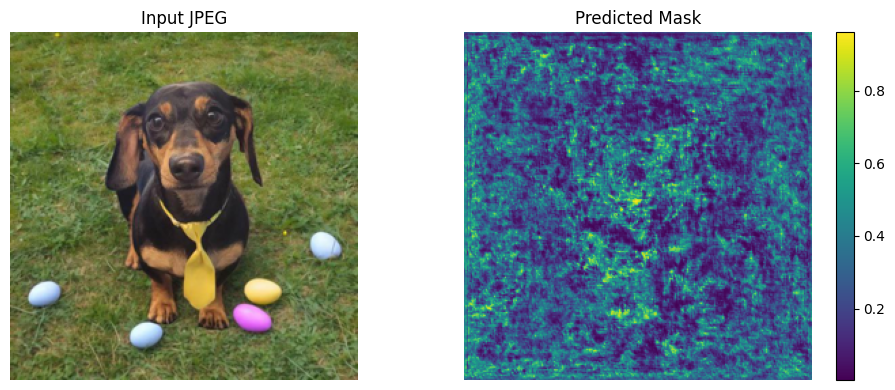

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Image from https://www.reddit.com/r/Dachshund/comments/1by5pso/barneys_easter_pic_a_week_late/
# Picked a dog since its a generic picture that the 
image_path = "DogExample.jpeg"  # change this

# Load image as RGB
img_pil = Image.open(image_path).convert("RGB")

# Resize to the size expected by the model/example
img_pil = img_pil.resize((256, 256))

# Convert to numpy in [0, 1]
img_np = np.array(img_pil).astype(np.float32) / 255.0

# Convert HWC -> CHW and add batch dimension
x = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

# Forward pass
with torch.no_grad():
    y = model(x)

# Convert logits to probabilities
y_prob = torch.sigmoid(y).detach().cpu()[0, 0].numpy()

# Get input image back for plotting
x_vis = x.detach().cpu()[0].permute(1, 2, 0).numpy()

# Plot input and output
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Input JPEG")
plt.imshow(x_vis)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(y_prob, cmap="viridis")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

The above example visualization is to demonstrate that even though the model's encoder is pretrained, we have to fine tune the decoder on our dataset. 

In [ ]:
# Takes about 13 minutes to download all the sample images
import os
from datasets import load_dataset


os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS"] = "1"

train_stream = load_dataset(
    "dgural/bdd100k",
    split="train",
    streaming=True
)

# first 500 samples for validation
val_subset = list(train_stream.take(500))

# reload stream, then skip first 500 and take 2000 for training
train_stream = load_dataset(
    "dgural/bdd100k",
    split="train",
    streaming=True
)

train_subset = list(train_stream.skip(500).take(2000))

print("Train samples:", len(train_subset))
print("Val samples:", len(val_subset))

Resolving data files:   0%|          | 0/20003 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20003 [00:00<?, ?it/s]

Train samples: 2000
Val samples: 500


In [ ]:
# Fine Tune
import os
from pathlib import Path
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [ ]:
BDD_ROOT = Path("/path/to/bdd100k")  # <-- change this
TRAIN_IMG_DIR = BDD_ROOT / "images" / "10k" / "train"
VAL_IMG_DIR   = BDD_ROOT / "images" / "10k" / "val"
TRAIN_MASK_DIR = BDD_ROOT / "labels" / "sem_seg" / "masks" / "train"
VAL_MASK_DIR   = BDD_ROOT / "labels" / "sem_seg" / "masks" / "val"

IMG_SIZE = 256        # 256 or 320 is a good "few hours" choice
BATCH_SIZE = 8        # reduce if you run out of VRAM
NUM_WORKERS = 4
EPOCHS = 5            # should fit within a few hours on a decent GPU
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 42

# set this to a smaller number for a faster first run
MAX_TRAIN_SAMPLES = 2000   # e.g. 2000 for a quick run
MAX_VAL_SAMPLES = 500     # e.g. 500

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [ ]:
class BDD100KSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=320, max_samples=None):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        
        self.image_paths = sorted(list(self.img_dir.glob("*.jpg")))
        if len(self.image_paths) == 0:
            self.image_paths = sorted(list(self.img_dir.glob("*.png")))
        
        if max_samples is not None:
            self.image_paths = self.image_paths[:max_samples]

        self.img_transform = T.Compose([
            T.Resize((img_size, img_size), interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),
        ])

        self.mask_resize = T.Resize(
            (img_size, img_size),
            interpolation=T.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_dir / (img_path.stem + ".png")

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        image = self.img_transform(image)
        mask = self.mask_resize(mask)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64))

        return image, mask

In [ ]:
# Build dataloaders
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train samples:", len(train_subset))
print("Val samples:", len(val_subset))

In [ ]:
# Visualize a sample
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Unique labels in first mask:", torch.unique(masks[0])[:50])

In [ ]:
import segmentation_models_pytorch as smp

NUM_CLASSES = 19   # adjust if your masks use a different class count

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

print("Model ready.")

In [ ]:
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False

def unfreeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = True

freeze_encoder(model)
print("Encoder frozen.")

In [ ]:
IGNORE_INDEX = 255

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

In [ ]:
@torch.no_grad()
def compute_batch_iou(logits, targets, num_classes=19, ignore_index=255):
    preds = torch.argmax(logits, dim=1)

    ious = []
    for cls in range(num_classes):
        pred_c = (preds == cls)
        target_c = (targets == cls)

        valid = (targets != ignore_index)
        pred_c = pred_c & valid
        target_c = target_c & valid

        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()

        if union > 0:
            ious.append(intersection / union)

    if len(ious) == 0:
        return 0.0
    return float(np.mean(ious))

@torch.no_grad()
def pixel_accuracy(logits, targets, ignore_index=255):
    preds = torch.argmax(logits, dim=1)
    valid = (targets != ignore_index)
    correct = (preds == targets) & valid
    return correct.sum().item() / max(valid.sum().item(), 1)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    running_iou = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_acc += pixel_accuracy(logits.detach(), masks)
        running_iou += compute_batch_iou(logits.detach(), masks, num_classes=NUM_CLASSES)

        pbar.set_postfix(loss=loss.item())

    n = len(loader)
    return running_loss / n, running_acc / n, running_iou / n


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    running_iou = 0.0

    pbar = tqdm(loader, desc="Val", leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks)

        running_loss += loss.item()
        running_acc += pixel_accuracy(logits, masks)
        running_iou += compute_batch_iou(logits, masks, num_classes=NUM_CLASSES)

    n = len(loader)
    return running_loss / n, running_acc / n, running_iou / n

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_iou": [],
    "val_iou": [],
}

best_val_iou = -1.0
best_path = "unet_bdd100k_best.pth"

for epoch in range(EPOCHS):
    if epoch == 1:
        unfreeze_encoder(model)
        optimizer = optim.AdamW(model.parameters(), lr=LR * 0.3, weight_decay=WEIGHT_DECAY)
        print("Encoder unfrozen.")

    train_loss, train_acc, train_iou = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device
    )
    val_loss, val_acc, val_iou = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
        f"train_iou={train_iou:.4f} val_iou={val_iou:.4f}"
    )

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), best_path)
        print(f"Saved best model to {best_path}")

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Pixel Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_iou"], label="train")
plt.plot(history["val_iou"], label="val")
plt.title("Mean IoU")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# simple color palette for up to 19 classes
PALETTE = np.array([
    [0, 0, 0],
    [128, 64, 128],
    [244, 35, 232],
    [70, 70, 70],
    [102, 102, 156],
    [190, 153, 153],
    [153, 153, 153],
    [250, 170, 30],
    [220, 220, 0],
    [107, 142, 35],
    [152, 251, 152],
    [70, 130, 180],
    [220, 20, 60],
    [255, 0, 0],
    [0, 0, 142],
    [0, 0, 70],
    [0, 60, 100],
    [0, 80, 100],
    [0, 0, 230],
], dtype=np.uint8)

def colorize_mask(mask):
    mask = np.clip(mask, 0, len(PALETTE) - 1)
    return PALETTE[mask]

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    logits = model(images)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

images_np = images.cpu().permute(0, 2, 3, 1).numpy()
masks_np = masks.numpy()

n_show = min(3, len(images_np))
plt.figure(figsize=(12, 4 * n_show))

for i in range(n_show):
    img = images_np[i]
    gt = masks_np[i]
    pred = preds[i]

    plt.subplot(n_show, 3, 3*i + 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 2)
    plt.imshow(colorize_mask(np.where(gt == IGNORE_INDEX, 0, gt)))
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 3)
    plt.imshow(colorize_mask(pred))
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "encoder_name": "resnet34",
}, "unet_bdd100k_final_checkpoint.pth")

print("Saved final checkpoint.")

[5 points] Evaluation. Compare your modified model against a baseline using appropriate evaluation metrics. Your results should include quantitative comparisons and, where relevant, qualitative outputs (e.g., generated images, detection results). You are expected to interpret your findings, not just report them. When appropriate, include statistical comparisons to support your conclusions. Analyze why the model improved or did not improve, discuss trade-offs, and identify limitations or failure cases.  

In [ ]:
# Evaluation Code

# TODO Analysis